# 03 - Entrenamiento de modelo predictivo de rendimiento agrícola

Este cuaderno prepara los datos, entrena un modelo de regresión y guarda el artefacto entrenado en la carpeta de modelos.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_theme(style='whitegrid')

project_root = Path(r'D:\GitHub\Ruta_aprendizaje_2024\06-Integración_con_el_Mundo_Real\Proyecto_4')
data_dir = project_root / 'data'
model_dir = project_root / 'models'
model_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_dir / 'yield_df.csv')
df = df.rename(columns={'Unnamed: 0': 'id'})
df = df.copy()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['hg/ha_yield'] = pd.to_numeric(df['hg/ha_yield'], errors='coerce')
df['average_rain_fall_mm_per_year'] = pd.to_numeric(df['average_rain_fall_mm_per_year'], errors='coerce')
df['pesticides_tonnes'] = pd.to_numeric(df['pesticides_tonnes'], errors='coerce')
df['avg_temp'] = pd.to_numeric(df['avg_temp'], errors='coerce')
df = df.dropna(subset=['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'])

df['pesticides_log'] = np.log1p(df['pesticides_tonnes'])
df['rainfall_log'] = np.log1p(df['average_rain_fall_mm_per_year'])
df['temp_rain_interaction'] = df['avg_temp'] * df['average_rain_fall_mm_per_year']
df['year_centered'] = df['Year'] - df['Year'].mean()

X = df[['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'pesticides_log', 'rainfall_log', 'temp_rain_interaction', 'year_centered']]
y = df['hg/ha_yield']

cat_features = ['Area', 'Item']
num_features = [c for c in X.columns if c not in cat_features]

preprocess = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
])

pipeline = Pipeline(steps=[('preprocess', preprocess), ('model', XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print('R2:', round(r2, 4))
print('MAE:', round(mae, 4))
print('RMSE:', round(rmse, 4))


R2: 0.9681
MAE: 9360.8416
RMSE: 15212.075


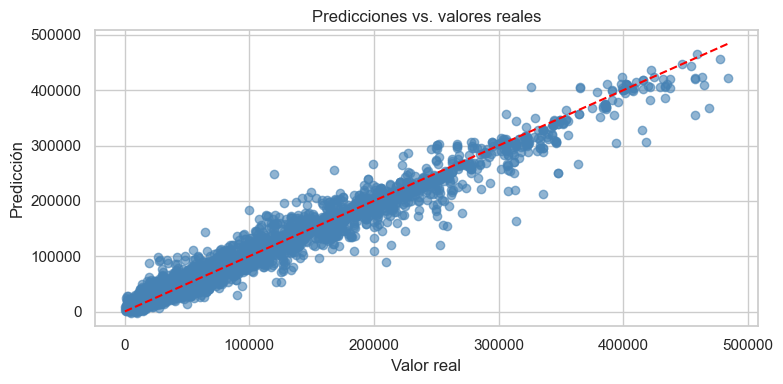

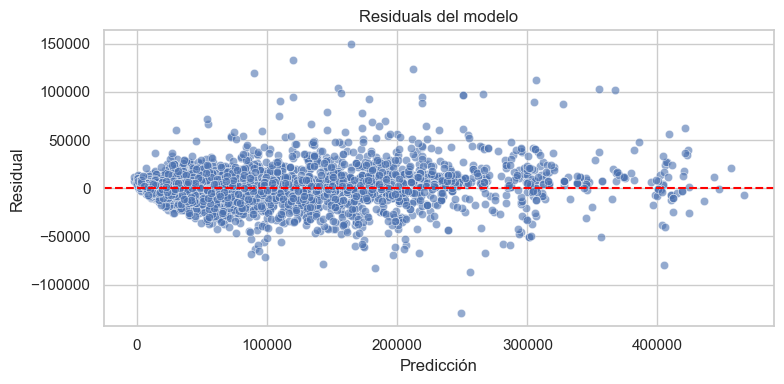

In [2]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test, preds, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.title('Predicciones vs. valores reales')
plt.tight_layout()
plt.show()

residuals = y_test - preds
plt.figure(figsize=(8, 4))
sns.scatterplot(x=preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicción')
plt.ylabel('Residual')
plt.title('Residuals del modelo')
plt.tight_layout()
plt.show()


In [3]:
model_path = model_dir / 'crop_yield_xgb_pipeline.joblib'
metrics_path = model_dir / 'model_metrics.json'
joblib.dump(pipeline, model_path)
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump({'r2': round(float(r2), 4), 'mae': round(float(mae), 4), 'rmse': round(float(rmse), 4)}, f, indent=2)

print('Modelo guardado en:', model_path)
print('Métricas guardadas en:', metrics_path)


Modelo guardado en: D:\GitHub\Ruta_aprendizaje_2024\06-Integración_con_el_Mundo_Real\Proyecto_4\models\crop_yield_xgb_pipeline.joblib
Métricas guardadas en: D:\GitHub\Ruta_aprendizaje_2024\06-Integración_con_el_Mundo_Real\Proyecto_4\models\model_metrics.json
